# Prueba de progreso 3: Predicción del daño de terremotos
## **Usuario: \_\_SHS\_\_**

## **Ranking: #1232**


## Introducción

En esta práctica se participa en la competición de DrivenData “Richter’s Predictor: Modeling Earthquake Damage”, cuyo objetivo es predecir el nivel de daño sufrido por edificios tras el terremoto de Gorkha (Nepal, 2015).

El problema consiste en predecir la variable damage_grade, que representa el nivel de daño sufrido por cada edificio tras el terremoto.

Los posibles valores son:

- 1 → daño bajo
- 2 → daño medio
- 3 → destrucción severa

Se trata de un problema de clasificación ordinal, ya que las clases tienen un orden natural.

A lo largo de esta práctica se realizará:

1. Carga de datos.
2. Limpieza y preprocesamiento.
3. Análisis exploratorio.
4. Preparación de variables.
5. Entrenamiento de modelos.
6. Evaluación mediante F1-score.
7. Generación del archivo de envío para DrivenData.

## Carga de datos

In [1]:
import pandas as pd

In [2]:
# cargamos los datasets
train_values = pd.read_csv("train_values.csv")

train_labels = pd.read_csv("train_labels.csv")

test_values = pd.read_csv("test_values.csv")

submission_format = pd.read_csv("submission_format.csv")

## Visualización inicial de los datasets

Ahora vamos a visualizar las primeras filas de cada dataset para:

- comprobar que se han cargado correctamente
- ver qué columnas tienen
- identificar tipos de variables
- detectar posibles problemas iniciales
- entender la estructura de los datos
- ver nombres de columnas
- comprobar formatos

In [3]:
print("TRAIN VALUES")
train_values.head()

TRAIN VALUES


,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other
0,802906,6,487,12198,2,30,6,5,t,r,...,0,0,0,0,0,0,0,0,0,0
1,28830,8,900,2812,2,10,8,7,o,r,...,0,0,0,0,0,0,0,0,0,0
2,94947,21,363,8973,2,10,5,5,t,r,...,0,0,0,0,0,0,0,0,0,0
3,590882,22,418,10694,2,10,6,5,t,r,...,0,0,0,0,0,0,0,0,0,0
4,201944,11,131,1488,3,30,8,9,t,r,...,0,0,0,0,0,0,0,0,0,0


In [4]:
print("TRAIN LABELS")
train_labels.head()

TRAIN LABELS


,building_id,damage_grade
0,802906,3
1,28830,2
2,94947,3
3,590882,2
4,201944,3


In [5]:
print("TEST VALUES")
test_values.head()

TEST VALUES


,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other
0,300051,17,596,11307,3,20,7,6,t,r,...,0,0,0,0,0,0,0,0,0,0
1,99355,6,141,11987,2,25,13,5,t,r,...,1,0,0,0,0,0,0,0,0,0
2,890251,22,19,10044,2,5,4,5,t,r,...,0,0,0,0,0,0,0,0,0,0
3,745817,26,39,633,1,0,19,3,t,r,...,0,0,1,0,0,0,0,0,0,0
4,421793,17,289,7970,3,15,8,7,t,r,...,0,0,0,0,0,0,0,0,0,0


## Primer análisis del dataset

Ahora vamos a comprobar el tamaño de los datasets.

In [6]:
# para entender shape lo que hace es devolver filas,columnas
print("filas y columnas de TRAIN VALUES:")
print(train_values.shape)

print("\nfilas y columnas de TRAIN LABELS:")
print(train_labels.shape)

print("\nfilas y columnas de TEST VALUES:")
print(test_values.shape)

filas y columnas de TRAIN VALUES:
(260601, 39)

filas y columnas de TRAIN LABELS:
(260601, 2)

filas y columnas de TEST VALUES:
(86868, 39)


Con esto comprobamos:

- que los datasets se han cargado completos
- cuántas variables tenemos
- si train y labels tienen el mismo número de filas

## Información general del dataset

Ahora veremos información más detallada del dataset de entrenamiento.

In [7]:
train_values.info()

<class 'pandas.DataFrame'>
RangeIndex: 260601 entries, 0 to 260600
Data columns (total 39 columns):
 #   Column                                  Non-Null Count   Dtype
---  ------                                  --------------   -----
 0   building_id                             260601 non-null  int64
 1   geo_level_1_id                          260601 non-null  int64
 2   geo_level_2_id                          260601 non-null  int64
 3   geo_level_3_id                          260601 non-null  int64
 4   count_floors_pre_eq                     260601 non-null  int64
 5   age                                     260601 non-null  int64
 6   area_percentage                         260601 non-null  int64
 7   height_percentage                       260601 non-null  int64
 8   land_surface_condition                  260601 non-null  str  
 9   foundation_type                         260601 non-null  str  
 10  roof_type                               260601 non-null  str  
 11  ground_floo

Observaciones iniciales

Se observa que:

- El dataset contiene un gran volumen de datos, con más de 260000 registros.
- Existen variables numéricas y categóricas.
- Las variables categóricas están representadas mediante letras.
- No parecen existir valores nulos, ya que todas las columnas tienen el mismo número de valores no nulos.
- building_id actúa como identificador único de cada edificio.
- La variable objetivo (damage_grade) se encuentra separada en otro dataset (train_labels).
- Será necesario realizar preprocesamiento antes de entrenar modelos de Machine Learning.

## Integración de datasets
### Unión de variables y etiquetas

El dataset de entrenamiento se encuentra dividido en dos archivos:

- train_values -> variables predictoras que es la info de los edificios es decir las columnas qe usa el modelo para aprender
- train_labels -> contiene la variable objetivo (damage_grade) es decir lo que queremos predecir

Por tanto, es necesario unir ambos datasets usando la columna común building_id.

In [8]:
# unimos variables y etiquetas mediante building_id
dataset_train = train_values.merge(
    train_labels,
    on="building_id",
    how="inner"
)

dataset_train.head()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
0,802906,6,487,12198,2,30,6,5,t,r,...,0,0,0,0,0,0,0,0,0,3
1,28830,8,900,2812,2,10,8,7,o,r,...,0,0,0,0,0,0,0,0,0,2
2,94947,21,363,8973,2,10,5,5,t,r,...,0,0,0,0,0,0,0,0,0,3
3,590882,22,418,10694,2,10,6,5,t,r,...,0,0,0,0,0,0,0,0,0,2
4,201944,11,131,1488,3,30,8,9,t,r,...,0,0,0,0,0,0,0,0,0,3


Se ha realizado una integración de datasets mediante merge utilizando:

- on="building_id" → columna común
- how="inner" → mantiene únicamente las filas coincidentes

Ahora dataset_train contiene:

- las variables predictoras
- la variable objetivo (damage_grade)

Todo en un único dataset listo para el análisis.

## Comprobación del nuevo dataset

In [9]:
# comprobamos que la integracion haya sifo correcta
dataset_train.shape

(260601, 40)

Con esto verificamos que:

- el número de filas sigue siendo correcto
- la variable objetivo se ha añadido correctamente
- ahora tenemos todas las variables en un único dataset

## Comprobación de duplicados
Antes de continuar es importante comprobar si existen edificios repetidos.

In [10]:
# comprobamos duplicados en building_id
dataset_train["building_id"].duplicated().sum()

np.int64(0)

Esto nos permite verificar si hay repetidos.
- no existen duplicados en el dataset

## Comprobación de valores nulos
Ahora vamos a comprobar si existen valores nulos en el dataset.

In [11]:
# comprobamos valores nulos
dataset_train.isnull().sum()

building_id                               0
geo_level_1_id                            0
geo_level_2_id                            0
geo_level_3_id                            0
count_floors_pre_eq                       0
age                                       0
area_percentage                           0
height_percentage                         0
land_surface_condition                    0
foundation_type                           0
roof_type                                 0
ground_floor_type                         0
other_floor_type                          0
position                                  0
plan_configuration                        0
has_superstructure_adobe_mud              0
has_superstructure_mud_mortar_stone       0
has_superstructure_stone_flag             0
has_superstructure_cement_mortar_stone    0
has_superstructure_mud_mortar_brick       0
has_superstructure_cement_mortar_brick    0
has_superstructure_timber                 0
has_superstructure_bamboo       

## Comprobación de variables categóricas
Ahora identificaremos las columnas categóricas del dataset.

In [12]:
# seleccionamos columnas categóricas
columnas_categoricas = dataset_train.select_dtypes(include=["object", "string"])

# mostramos nombres de columnas
columnas_categoricas.columns

Index(['land_surface_condition', 'foundation_type', 'roof_type',
       'ground_floor_type', 'other_floor_type', 'position',
       'plan_configuration', 'legal_ownership_status'],
      dtype='str')

Se observa que existen 8 variables categóricas:

- land_surface_condition
- foundation_type
- roof_type
- ground_floor_type
- other_floor_type
- position
- plan_configuration
- legal_ownership_status

Estas variables están representadas mediante letras, por lo que posteriormente será necesario convertirlas a formato numérico para poder utilizarlas en modelos de Machine Learning.

# Análisis exploratorio de datos (EDA)

Ahora realizaremos un análisis exploratorio del dataset con el objetivo de:

- entender mejor la distribución de los datos
- analizar la variable objetivo
- detectar posibles desequilibrios entre clases
- estudiar relaciones entre variables
- obtener información útil para el entrenamiento de modelos

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

## Distribución de la variable objetivo

Vamos a analizar cómo se distribuyen las clases de daño para comprobar si el dataset está balanceado o no.

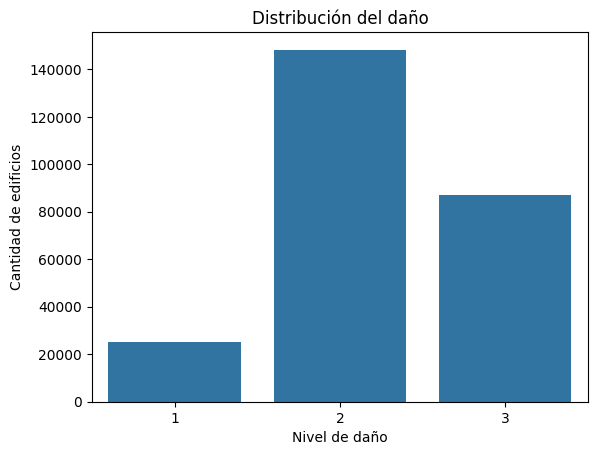

In [14]:
sns.countplot(data=dataset_train, x="damage_grade")

plt.title("Distribución del daño")
plt.xlabel("Nivel de daño")
plt.ylabel("Cantidad de edificios")

plt.show()

Observamos que las clases no están completamente balanceadas.

La clase más frecuente es:

- damage_grade = 2 → daño medio

Mientras que:

- damage_grade = 1 tiene muchos menos ejemplos
- damage_grade = 3 presenta una cantidad intermedia

Esto indica que existe cierto desbalanceo en el dataset.

Este aspecto es importante porque algunos modelos de Machine Learning pueden verse afectados por clases desbalanceadas.

Por este motivo, la evaluación mediante F1-score será más adecuada que utilizar únicamente accuracy.

## Estadísticas descriptivas

Ahora analizaremos estadísticas descriptivas de las variables numéricas del dataset.

Esto nos permitirá:

- conocer rangos de valores
- analizar medias y desviaciones
- detectar posibles valores extremos
- comprender mejor la escala de las variables

In [15]:
dataset_train.describe()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
count,2.606010e+05,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,...,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000
mean,5.256755e+05,13.900353,701.074685,6257.876148,2.129723,26.535029,8.018051,5.434365,0.088645,0.761935,...,0.033626,0.008101,0.000940,0.000361,0.001071,0.000188,0.000146,0.000088,0.005119,2.238272
std,3.045450e+05,8.033617,412.710734,3646.369645,0.727665,73.565937,4.392231,1.918418,0.284231,0.425900,...,0.180265,0.089638,0.030647,0.018989,0.032703,0.013711,0.012075,0.009394,0.071364,0.611814
min,4.000000e+00,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.611900e+05,7.000000,350.000000,3073.000000,2.000000,10.000000,5.000000,4.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,5.257570e+05,12.000000,702.000000,6270.000000,2.000000,15.000000,7.000000,5.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,7.897620e+05,21.000000,1050.000000,9412.000000,2.000000,30.000000,9.000000,6.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,1.052934e+06,30.000000,1427.000000,12567.000000,9.000000,995.000000,100.000000,32.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000


## Distribución de variables numéricas

Ahora analizaremos la distribución de algunas variables numéricas relevantes.

Esto nos permitirá:

- observar la forma de las distribuciones
- detectar posibles asimetrías
- identificar valores extremos
- comprender mejor el comportamiento de las variables

### Distribución de la edad de los edificios

Analizamos la variable age para observar:

- antigüedad de los edificios
- posibles asimetrías
- presencia de valores extremos

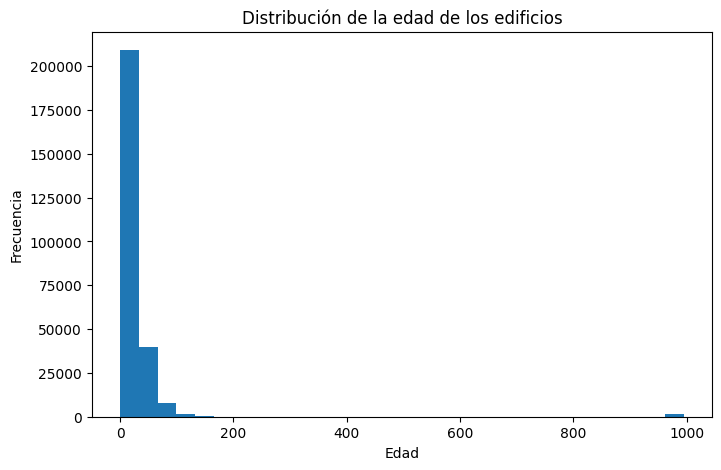

In [16]:
plt.figure(figsize=(8,5))

plt.hist(dataset_train["age"], bins=30)

plt.title("Distribución de la edad de los edificios")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

plt.show()

La mayoría de edificios presentan edades relativamente bajas, concentrándose principalmente en valores inferiores a 100 años.

Sin embargo, también aparecen algunos edificios con edades extremadamente altas, cercanas a 1000 años, lo que indica la presencia de posibles valores atípicos (outliers).

### Distribución del número de pisos

Ahora analizamos cuántas plantas tienen los edificios antes del terremoto.

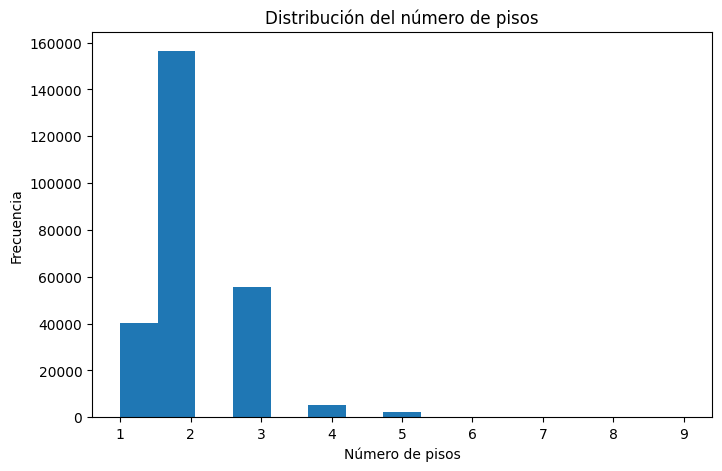

In [17]:
plt.figure(figsize=(8,5))

plt.hist(dataset_train["count_floors_pre_eq"], bins=15)

plt.title("Distribución del número de pisos")
plt.xlabel("Número de pisos")
plt.ylabel("Frecuencia")

plt.show()

La mayoría de edificios poseen entre 1 y 3 pisos.

A medida que aumenta el número de pisos, la frecuencia disminuye considerablemente.

Esto indica que predominan construcciones relativamente bajas, mientras que los edificios muy altos son poco frecuentes.

### Distribución del porcentaje de área

Analizamos la distribución del tamaño relativo de los edificios.

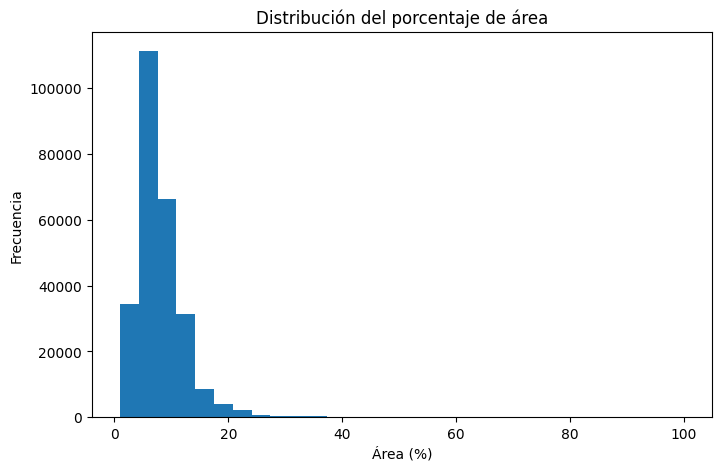

In [18]:
plt.figure(figsize=(8,5))

plt.hist(dataset_train["area_percentage"], bins=30)

plt.title("Distribución del porcentaje de área")
plt.xlabel("Área (%)")
plt.ylabel("Frecuencia")

plt.show()

La distribución del área presenta una concentración importante en valores bajos y medios.

La mayoría de edificios ocupan porcentajes de área reducidos, mientras que existen pocos edificios con áreas muy grandes.

### Distribución del porcentaje de altura

Ahora observamos cómo se distribuye la altura relativa de los edificios.

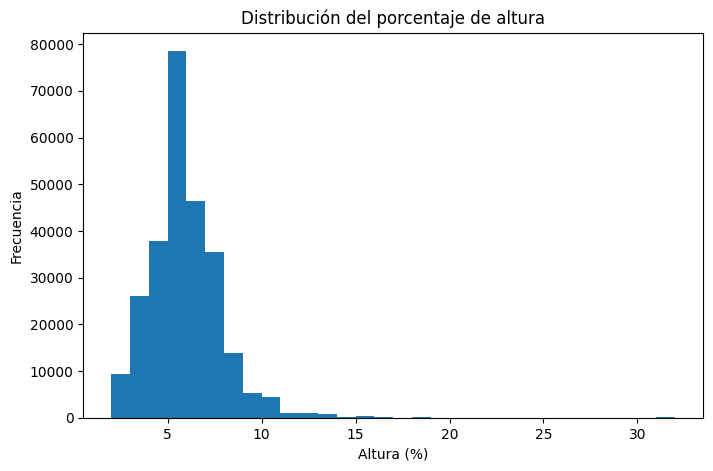

In [19]:
plt.figure(figsize=(8,5))

plt.hist(dataset_train["height_percentage"], bins=30)

plt.title("Distribución del porcentaje de altura")
plt.xlabel("Altura (%)")
plt.ylabel("Frecuencia")

plt.show()

La altura relativa de los edificios se concentra principalmente en valores bajos y medios.

Existen pocos edificios con porcentajes de altura elevados, lo que sugiere que la mayoría de construcciones tienen alturas moderadas.

## Correlaciones

In [20]:
corr = dataset_train.corr(numeric_only=True)

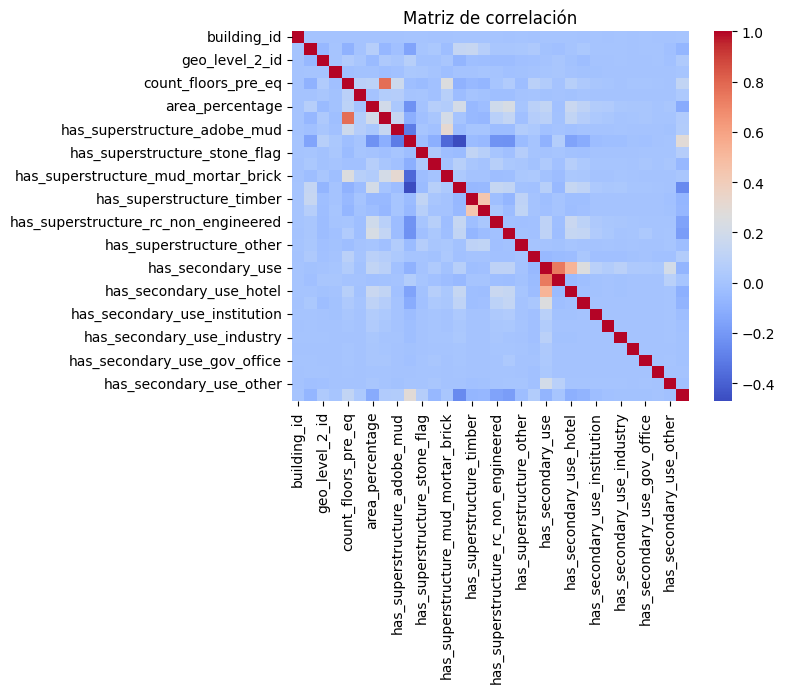

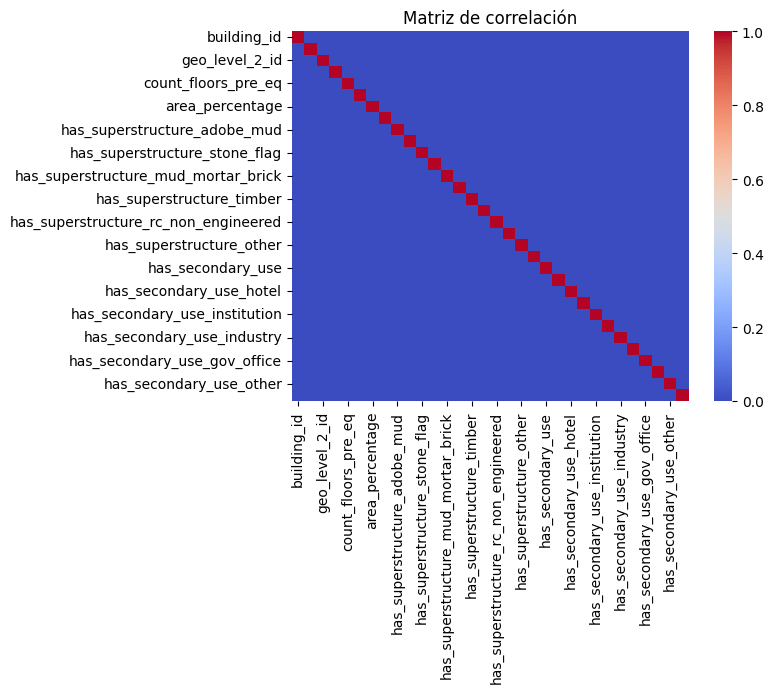

In [21]:
sns.heatmap(corr, cmap="coolwarm")

plt.title("Matriz de correlación")

plt.show()



sns.heatmap(
    corr.abs() > 0.9,
    cmap="coolwarm"
)

plt.title("Matriz de correlación")

plt.show()

La matriz de correlación permite observar la relación entre las variables numéricas del dataset.

En general, no se observan correlaciones extremadamente altas entre la mayoría de variables.

## Preparación y preprocesamiento de datos

En esta fase prepararemos los datos para poder entrenar modelos de Machine Learning.

Los objetivos principales serán:

- separar variables predictoras y variable objetivo
- transformar variables categóricas a formato numérico
- dividir los datos en entrenamiento y validación
- dejar el dataset listo para entrenar modelos

## Separación de variables predictoras y variable objetivo

Primero separaremos:

- X → variables predictoras
- y → variable objetivo (damage_grade)

In [22]:
# variables predictoras
X = dataset_train.drop("damage_grade", axis=1)

# variable objetivo
y = dataset_train["damage_grade"]

## Eliminación de identificadores

La variable building_id actúa únicamente como identificador único del edificio.

No aporta info útil para la predicción, por lo que la eliminaremos.

In [23]:
X = X.drop("building_id", axis=1)

test_values_model = test_values.drop("building_id", axis=1)

## Transformación de variables categóricas

Los modelos de Machine Learning trabajan con valores numéricos, entonces transformamos las variables categoricas en numéricas.

In [24]:
X = pd.get_dummies(X)

test_values_model = pd.get_dummies(test_values_model)

## Alineación de columnas

Es importante asegurarnos de que los datasets de entrenamiento y test tienen exactamente las mismas columnas.

In [25]:
X, test_values_model = X.align(
    test_values_model,
    join="left",
    axis=1,
    fill_value=0
)

## División en entrenamiento y validación

Ahora dividiremos los datos para poder evaluar los modelos antes de generar predicciones finales, usamos:

- 80% entrenamiento
- 20% validación

In [26]:
from sklearn.model_selection import train_test_split

# dividimos los datos
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) 
# stratify=y mantiene la misma proporción de clases en entrenamiento y validación

## Escalado de variables

Algunos modelos de Machine Learning son sensibles a la escala de las variables, como:

- KNN
- Gaussian Naive Bayes

Por este motivo, realizaremos una normalización de los datos utilizando StandardScaler.



In [27]:
from sklearn.preprocessing import StandardScaler

# creamos el scaler
scaler = StandardScaler()

# ajustamos sobre train y transformamos
X_train_scaled = scaler.fit_transform(X_train)

# transformamos validacion
X_valid_scaled = scaler.transform(X_valid)

# transformamos test
test_scaled = scaler.transform(test_values_model)

In [28]:
# porcentaje de cada clase
y.value_counts(normalize=True) * 100

damage_grade
2    56.891186
3    33.468022
1     9.640792
Name: proportion, dtype: float64

Observamos que las clases no están completamente balanceadas.

La clase 2 es la más frecuente, mientras que la clase 1 tiene menos ejemplos.

Esto refuerza la necesidad de utilizar métricas robustas como F1-score.

# Entrenamiento y evaluación de modelos

En esta sección se entrenarán distintos modelos de Machine Learning con el objetivo de comparar su rendimiento en la predicción del daño de edificios.

Se probarán distintos algoritmos vistos en clase:

- KNN
- Gaussian Naive Bayes
- Árbol de decisión
- Bagging
- Random Forest
- Gradient Boosting

Además, algunos modelos utilizarán datos escalados, ya que son sensibles a la magnitud de las variables.

La evaluación se realizará utilizando F1-score, ya que el dataset presenta cierto desbalanceo entre clases.

In [29]:
from sklearn.metrics import f1_score

from sklearn.model_selection import GridSearchCV

## KNN

In [30]:
from sklearn.neighbors import KNeighborsClassifier

# creamos modelo
knn = KNeighborsClassifier(n_neighbors=5)

# entrenamos
knn.fit(X_train_scaled, y_train)

# predicciones
pred_knn = knn.predict(X_valid_scaled)

# f1-score
f1_knn = f1_score(y_valid, pred_knn, average="weighted")

print("F1-score KNN:", f1_knn)

F1-score KNN: 0.6414591773943716


## KNN con hiperparametros y optimizado

In [31]:
## KNN con GridSearchCV

from sklearn.neighbors import KNeighborsClassifier

# modelo base
knn = KNeighborsClassifier()

# hiperparámetros
param_grid_knn = {
    "n_neighbors": [3, 5, 7],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

# grid search
grid_knn = GridSearchCV(
    estimator=knn,
    param_grid=param_grid_knn,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1
)

# entrenamiento
grid_knn.fit(X_train_scaled, y_train)

# mejor modelo
best_knn = grid_knn.best_estimator_

# mejores parámetros
print("Mejores parámetros KNN:")
print(grid_knn.best_params_)

# predicciones
pred_knn = best_knn.predict(X_valid_scaled)

# f1-score
f1_knn_op = f1_score(
    y_valid,
    pred_knn,
    average="weighted"
)

print("F1-score KNN:", f1_knn_op)

Mejores parámetros KNN:
{'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}
F1-score KNN: 0.6635235611308399


## Gaussian Naive Bayes

In [32]:
from sklearn.naive_bayes import GaussianNB

# creamos modelo
nb = GaussianNB()

# entrenamos
nb.fit(X_train_scaled, y_train)

# predicciones
pred_nb = nb.predict(X_valid_scaled)

# f1-score
f1_nb = f1_score(y_valid, pred_nb, average="weighted")

print("F1-score GaussianNB:", f1_nb)

F1-score GaussianNB: 0.3183036879329688


No se ha hecho el Bayes hiperparametrizado ya que no tiene muchos parametros

## Árbol de decisión

In [33]:
from sklearn.tree import DecisionTreeClassifier

# creamos el modelo
tree = DecisionTreeClassifier(random_state=42)

# entrenamos
tree.fit(X_train, y_train)

# predicciones
pred_tree = tree.predict(X_valid)

# calculamos f1-score
f1_tree = f1_score(y_valid, pred_tree, average="weighted")

print("F1-score Decision Tree:", f1_tree)

F1-score Decision Tree: 0.6587024348415356


## Árbol de decisión con hiperparametros y optimizado

In [ ]:
# definimos los hiperparámetros
param_grid_tree = {
    "max_depth": [5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"]# El criterion define cómo el árbol decide la mejor división de los datos. Probamos gini y entropy para ver cuál separaba mejor las clases.
}

# creamos modelo base
tree_base = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

# grid search con validación cruzada
grid_tree = GridSearchCV(
    estimator=tree_base,
    param_grid=param_grid_tree,
    scoring="f1_weighted",
    cv=5,
    n_jobs=-1
)

# entrenamos búsqueda
grid_tree.fit(X_train, y_train)

# mejor modelo encontrado
best_tree = grid_tree.best_estimator_

# predicciones
pred_tree_opt = best_tree.predict(X_valid)

# f1-score
f1_tree_opt = f1_score(
    y_valid,
    pred_tree_opt,
    average="weighted"
)

print("Mejores parámetros:")
print(grid_tree.best_params_)

print("F1-score Decision Tree optimizado:", f1_tree_opt)

Mejores parámetros:
{'criterion': 'gini', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2}
F1-score Decision Tree optimizado: 0.6575817135009823


## Bagging

In [35]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

# modelo base
tree_base = DecisionTreeClassifier(random_state=42)

# modelo bagging
bagging = BaggingClassifier(
    estimator=tree_base,
    n_estimators=100,
    max_samples=0.8,
    random_state=42,
    n_jobs=-1
)

# entrenamos
bagging.fit(X_train, y_train)

# predicciones
pred_bag = bagging.predict(X_valid)

# f1-score
f1_bag = f1_score(y_valid, pred_bag, average="weighted")

print("F1-score Bagging:", f1_bag)

F1-score Bagging: 0.7252744271475106


## Bagging con hiperparametros y optimizado

In [36]:
## Bagging con GridSearchCV

# modelo base
tree_base = DecisionTreeClassifier(max_depth=20, min_samples_leaf=2,random_state=42)

# modelo bagging
bagging = BaggingClassifier(
    estimator=tree_base,
    random_state=42,
    n_jobs=-1
)

# hiperparámetros
param_grid_bag = {
    "n_estimators": [100, 200],
    "max_samples": [0.6, 0.8, 1.0]
}

# grid search
grid_bag = GridSearchCV(
    estimator=bagging,
    param_grid=param_grid_bag,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1
)

# entrenamiento
grid_bag.fit(X_train, y_train)

# mejor modelo
best_bag = grid_bag.best_estimator_

# mejores parámetros
print("Mejores parámetros Bagging:")
print(grid_bag.best_params_)

# predicciones
pred_bag = best_bag.predict(X_valid)

# f1-score
f1_bag_op = f1_score(
    y_valid,
    pred_bag,
    average="weighted"
)

print("F1-score Bagging:", f1_bag_op)

Mejores parámetros Bagging:
{'max_samples': 0.6, 'n_estimators': 200}
F1-score Bagging: 0.7350664940228668


## Random Forest

In [37]:
from sklearn.ensemble import RandomForestClassifier

# creamos el modelo
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# entrenamos
rf.fit(X_train, y_train)

# predicciones
pred_rf = rf.predict(X_valid)

# f1-score
f1_rf = f1_score(y_valid, pred_rf, average="weighted")

print("F1-score Random Forest:", f1_rf)

F1-score Random Forest: 0.710294976375269


## Random Forest con hiperparametros y optimizado

In [38]:
## Random Forest con GridSearchCV

# modelo base
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# hiperparámetros a probar
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "class_weight": [None, "balanced"]
}

# grid search
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1
)

# entrenamiento
grid_rf.fit(X_train, y_train)

# mejor modelo
best_rf = grid_rf.best_estimator_

# mejores parámetros
print("Mejores parámetros RF:")
print(grid_rf.best_params_)

# predicciones
pred_rf = best_rf.predict(X_valid)

# f1-score
f1_rf_op = f1_score(
    y_valid,
    pred_rf,
    average="weighted"
)

print("F1-score Random Forest:", f1_rf_op)

Mejores parámetros RF:
{'class_weight': None, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
F1-score Random Forest: 0.7176919970690493


## Gradient Boosting

In [39]:
from sklearn.ensemble import GradientBoostingClassifier

# creamos modelo
gb = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42
)

# entrenamos
gb.fit(X_train, y_train)

# predicciones
pred_gb = gb.predict(X_valid)

# f1-score
f1_gb = f1_score(y_valid, pred_gb, average="weighted")

print("F1-score Gradient Boosting:", f1_gb)

F1-score Gradient Boosting: 0.6647741119741102


## Gradient Boosting con hiperparametros y optimizado

In [40]:
""""from sklearn.model_selection import GridSearchCV

# hiperparámetros
param_grid_gb = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [3, 5]
}

# modelo base
gb_base = GradientBoostingClassifier(
    random_state=42
)

# grid search
grid_gb = GridSearchCV(
    estimator=gb_base,
    param_grid=param_grid_gb,
    scoring="f1_weighted",
    cv=3,
    n_jobs=-1
)

# entrenamiento
grid_gb.fit(X_train, y_train)

# mejor modelo
best_gb = grid_gb.best_estimator_

# predicciones
pred_gb_opt = best_gb.predict(X_valid)

# f1-score
f1_gb_opt = f1_score(
    y_valid,
    pred_gb_opt,
    average="weighted"
)

print("Mejores parámetros:")
print(grid_gb.best_params_)

print("F1-score Gradient Boosting optimizado:", f1_gb_opt)"""

'"from sklearn.model_selection import GridSearchCV\n\n# hiperparámetros\nparam_grid_gb = {\n    "n_estimators": [50, 100, 200],\n    "learning_rate": [0.01, 0.1, 0.2],\n    "max_depth": [3, 5]\n}\n\n# modelo base\ngb_base = GradientBoostingClassifier(\n    random_state=42\n)\n\n# grid search\ngrid_gb = GridSearchCV(\n    estimator=gb_base,\n    param_grid=param_grid_gb,\n    scoring="f1_weighted",\n    cv=3,\n    n_jobs=-1\n)\n\n# entrenamiento\ngrid_gb.fit(X_train, y_train)\n\n# mejor modelo\nbest_gb = grid_gb.best_estimator_\n\n# predicciones\npred_gb_opt = best_gb.predict(X_valid)\n\n# f1-score\nf1_gb_opt = f1_score(\n    y_valid,\n    pred_gb_opt,\n    average="weighted"\n)\n\nprint("Mejores parámetros:")\nprint(grid_gb.best_params_)\n\nprint("F1-score Gradient Boosting optimizado:", f1_gb_opt)'

Debido a la gran cantidad de tiempo que tarda en ejecutar he decidido comentarlo. Su puntuacion ha sido de 0.727784, aunque es mejor que el gradient boosting sin hiperparametros no merece la pena por la gran cantidad de tiempo que tarda en ejecutar.

## Comparación de resultados

In [41]:
# creamos tabla comparativa
resultados = pd.DataFrame({
    "Modelo": [
        "KNN",
        "KNN Optimizado",
        "GaussianNB",
        "Decision Tree",
        "Decision Tree Optimizado",
        "Bagging",
        "Bagging Optimizado",
        "Random Forest",
        "Random Forest Optimizado",
        "Gradient Boosting",
    ],
    "F1-score": [
        f1_knn,
        f1_knn_op,
        f1_nb,
        f1_tree,
        f1_tree_opt,
        f1_bag,
        f1_bag_op,
        f1_rf,
        f1_rf_op,
        f1_gb
    ]
})

# ordenamos de mayor a menor
resultados = resultados.sort_values(
    by="F1-score",
    ascending=False
)

resultados

,Modelo,F1-score
6,Bagging Optimizado,0.735066
5,Bagging,0.725274
8,Random Forest Optimizado,0.717692
7,Random Forest,0.710295
9,Gradient Boosting,0.664774
1,KNN Optimizado,0.663524
3,Decision Tree,0.658702
4,Decision Tree Optimizado,0.657582
0,KNN,0.641459
2,GaussianNB,0.318304


Observamos que los mejores resultados se obtienen mediante métodos de ensamblado.

El modelo con mejor rendimiento ha sido Bagging Optimizado, obteniendo un F1-score aproximado de 0.73.

Random Forest también obtiene resultados muy competitivos, confirmando que los métodos basados en múltiples árboles funcionan especialmente bien en este problema.

Por otro lado:

- KNN obtiene menor rendimiento debido a la alta dimensionalidad del dataset.
- Gaussian Naive Bayes presenta el peor resultado, probablemente porque las variables no cumplen la hipótesis de independencia.

En general, los modelos de ensamblado muestran mayor capacidad de generalización y mejor comportamiento frente al desbalanceo de clases.

## Ajustar Bagging

### Bagging ajustado

In [42]:
bag_opt = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=20,
        min_samples_leaf=2,
        random_state=42
    ),
    n_estimators=200,
    max_samples=0.8,
    random_state=42,
    n_jobs=-1
)

bag_opt.fit(X_train, y_train)

pred_bag_opt = bag_opt.predict(X_valid)

f1_bag_ajust = f1_score(
    y_valid,
    pred_bag_opt,
    average="weighted"
)

print("F1-score Bagging optimizado:", f1_bag_ajust)

F1-score Bagging optimizado: 0.7356141915737799


En este modelo lo que se ha hecho ha sido ir haciendo pruebas de forma manual hasta obtener un socre alto

## Comparación final de modelos

In [43]:
resultados_finales = pd.DataFrame({
    "Modelo": [
        "KNN",
        "KNN Optimizado",
        "GaussianNB",
        "Decision Tree",
        "Decision Tree Optimizado",
        "Bagging",
        "Bagging Optimizado",
        "Bagging Ajustado",
        "Random Forest",
        "Random Forest Optimizado",
        "Gradient Boosting", 
    ],
    "F1-score": [
        f1_knn,
        f1_knn_op,
        f1_nb,
        f1_tree,
        f1_tree_opt,
        f1_bag,
        f1_bag_op,
        f1_bag_ajust,
        f1_rf,
        f1_rf_op,
        f1_gb
    ]
})

resultados_finales = resultados_finales.sort_values(
    by="F1-score",
    ascending=False
)

resultados_finales

,Modelo,F1-score
7,Bagging Ajustado,0.735614
6,Bagging Optimizado,0.735066
5,Bagging,0.725274
9,Random Forest Optimizado,0.717692
8,Random Forest,0.710295
10,Gradient Boosting,0.664774
1,KNN Optimizado,0.663524
3,Decision Tree,0.658702
4,Decision Tree Optimizado,0.657582
0,KNN,0.641459


El mejor rendimiento se obtiene mediante Bagging ajustado, alcanzando un F1-score aproximado de 0.736.

Los modelos basados en distancia o hipótesis simplificadas, como KNN y Gaussian Naive Bayes, muestran menor capacidad de generalización en este problema.

## Entrenamiento final del mejor modelo

Utilizaremos el mejor modelo obtenido anteriormente: Bagging optimizado.

Ahora entrenaremos el modelo utilizando todos los datos disponibles de entrenamiento para maximizar el rendimiento antes de generar las predicciones finales.

In [44]:
# entrenamos el mejor modelo con TODOS los datos

bag_final = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=20,
        min_samples_leaf=2,
        random_state=42
    ),
    n_estimators=200,
    max_samples=0.8,
    random_state=42,
    n_jobs=-1
)

bag_final.fit(X, y)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...ndom_state=42)
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",200
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",0.8
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


## Generación de predicciones sobre test

Ahora utilizamos el modelo entrenado para predecir el nivel de daño de los edificios del dataset de test.

In [45]:
# generamos predicciones finales

test_predictions = bag_final.predict(test_values_model)

## Creación del archivo submission

In [46]:
# creamos dataframe submission

submission = pd.DataFrame({
    "building_id": test_values["building_id"],
    "damage_grade": test_predictions
})

submission.head()

,building_id,damage_grade
0,300051,3
1,99355,2
2,890251,2
3,745817,1
4,421793,3


## Exportación del archivo CSV

In [47]:
# exportamos csv final

submission.to_csv(
    "submission.csv",
    index=False
)

print("Archivo submission.csv generado correctamente")

Archivo submission.csv generado correctamente


## __Conclusiones y decisiones tomadas__

### __Uso de técnicas no supervisadas__

Se consideró la posibilidad de utilizar técnicas no supervisadas como PCA.

Sin embargo, finalmente no se aplicaron debido a que:

- los modelos basados en árboles manejan correctamente muchas variables
- las pruebas iniciales no indicaban mejoras claras en el rendimiento

Además, reducir dimensionalidad podía provocar pérdida de información relevante para la predicción.

### __Uso de modelos de regresión__

Aunque el problema puede considerarse parcialmente ordinal, finalmente se decidió utilizar únicamente modelos de clasificación.

Esto se debe a que:

- los modelos de clasificación ofrecían mejores resultados
- los algoritmos de ensamblado funcionaban especialmente bien en este problema

Por tanto, no fue necesario aplicar modelos de regresión.

### __Uso de SVM__

No se han utilizado modelos SVM debido al gran tamaño del dataset.

El conjunto de datos contiene más de 260000 edificios, por lo que el entrenamiento de SVM puede tardar mucho tiempo.

Además, otros modelos como Bagging y Random Forest ya obtenían mejores resultados con menor coste computacional, por lo que no fue necesario utilizar SVM.